# Ejercicio 8 – Incorporación de 2025 y análisis completo

En este notebook se incorporan los datos de **2025** y se analiza la evolución de los indicadores entre **2024, 2025 y 2026** para taxis amarillos y verdes.

Pasos:

1. descargar 2025 con el mismo sistema y verificar que no se repitan descargas (8.1–8.2);
2. comprobar que todas las consultas anteriores funcionan con el conjunto ampliado (8.3);
3. reconstruir los indicadores y el tablero con los tres años (8.4);
4. analizar la evolución e identificar cambios y patrones (8.5–8.6).

Las consultas sobre los viajes usan la misma configuración de memoria de los ejercicios anteriores (`memory_limit = 1GB`, `threads = 2`). El análisis de la evolución se hace sobre las tablas de indicadores (`data/processed/tablero.duckdb`), que son pequeñas.

In [1]:
import os
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

# Se trabaja desde la raiz del proyecto para que las rutas data/raw/... funcionen
if Path.cwd().name == "notebooks":
    os.chdir("..")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

CONFIG = {"memory_limit": "1GB", "threads": 2, "preserve_insertion_order": False}
COLORES = {"yellow": "#E0A800", "green": "#2E8B57"}
COLORES_ANIO = {2024: "#9E9E9E", 2025: "#1F77B4", 2026: "#D62728"}

# Conexion sobre los Parquet (validaciones y consultas anteriores)
con = duckdb.connect(config=CONFIG)


def consulta(ruta, conexion=None) -> pd.DataFrame | None:
    """Muestra y ejecuta un archivo SQL; devuelve el resultado como DataFrame (None si no hay resultado)."""
    sql = Path(ruta).read_text()
    print(sql)
    resultado = (conexion or con).sql(sql)
    return resultado.df() if resultado is not None else None

## 8.1–8.2 Descarga de 2025

Igual que con 2024, **no fue necesario modificar el script**: basta con agregar el año al argumento `--anio`.

```bash
python scripts/download_data.py --anio 2024 2025 2026
```

La primera ejecución (fuera de este notebook) descargó los 24 archivos de 2025 y omitió los 40 existentes. Los 24 archivos nuevos coinciden en tamaño con el `Content-Length` del servidor. A continuación se ejecuta el comando otra vez.

In [2]:
!python scripts/download_data.py --anio 2024 2025 2026


=== YELLOW 2024 ===
  2024-01  ya existe, se omite
  2024-02  ya existe, se omite
  2024-03  ya existe, se omite
  2024-04  ya existe, se omite
  2024-05  ya existe, se omite
  2024-06  ya existe, se omite
  2024-07  ya existe, se omite
  2024-08  ya existe, se omite
  2024-09  ya existe, se omite
  2024-10  ya existe, se omite
  2024-11  ya existe, se omite
  2024-12  ya existe, se omite

=== GREEN 2024 ===
  2024-01  ya existe, se omite
  2024-02  ya existe, se omite
  2024-03  ya existe, se omite
  2024-04  ya existe, se omite
  2024-05  ya existe, se omite
  2024-06  ya existe, se omite
  2024-07  ya existe, se omite
  2024-08  ya existe, se omite
  2024-09  ya existe, se omite
  2024-10  ya existe, se omite
  2024-11  ya existe, se omite
  2024-12  ya existe, se omite

=== YELLOW 2025 ===
  2025-01  ya existe, se omite
  2025-02  ya existe, se omite
  2025-03  ya existe, se omite
  2025-04  ya existe, se omite
  2025-05  ya existe, se omite
  2025-06  ya existe, se omite
  2025-0

  2026-09  aun no publicado por la TLC


  2026-10  aun no publicado por la TLC


  2026-11  aun no publicado por la TLC


  2026-12  aun no publicado por la TLC

=== GREEN 2026 ===
  2026-01  ya existe, se omite
  2026-02  ya existe, se omite
  2026-03  ya existe, se omite
  2026-04  ya existe, se omite
  2026-05  ya existe, se omite
  2026-06  ya existe, se omite
  2026-07  ya existe, se omite
  2026-08  ya existe, se omite


  2026-09  aun no publicado por la TLC


  2026-10  aun no publicado por la TLC


  2026-11  aun no publicado por la TLC


  2026-12  aun no publicado por la TLC

RESUMEN
  descargados   : 0
  ya existian   : 64
  no publicados : 8
      yellow 2026-09, yellow 2026-10, yellow 2026-11, yellow 2026-12, green 2026-09, green 2026-10, green 2026-11, green 2026-12
  fallidos      : 0


**Resultado:**

| Ejecución | Descargados | Ya existían | No publicados | Fallidos |
|-----------|------------:|------------:|--------------:|---------:|
| 1ª (descarga de 2025) | 24 | 40 | 8 | 0 |
| 2ª (esta celda) | 0 | 64 | 8 | 0 |

Los archivos de 2024 y 2026 no se volvieron a descargar.

### Verificación de los archivos y del esquema

Se reutilizan, sin cambios, las consultas de validación del Ejercicio 5 (`sql/05_incorporacion/`).

In [3]:
consulta("sql/05_incorporacion/01_archivos_por_anio.sql")

-- Ejercicio 5 - Archivos disponibles por tipo de taxi y anio, con el primer y ultimo mes.
-- Fuente: data/raw/*/*/*.parquet.
SELECT
    split_part(file, '/', 3)                                    AS tipo,
    split_part(file, '/', 4)                                    AS anio,
    count(*)                                                    AS archivos,
    min(regexp_extract(file, '(\d{4}-\d{2})\.parquet', 1))      AS primer_mes,
    max(regexp_extract(file, '(\d{4}-\d{2})\.parquet', 1))      AS ultimo_mes
FROM glob('data/raw/*/*/*.parquet')
GROUP BY tipo, anio
ORDER BY tipo, anio;



,tipo,anio,archivos,primer_mes,ultimo_mes
0,green,2024,12,2024-01,2024-12
1,green,2025,12,2025-01,2025-12
2,green,2026,8,2026-01,2026-08
3,yellow,2024,12,2024-01,2024-12
4,yellow,2025,12,2025-01,2025-12
5,yellow,2026,8,2026-01,2026-08


In [4]:
consulta("sql/05_incorporacion/02_registros_por_anio.sql")

-- Ejercicio 5 - Registros por tipo de taxi y anio segun los metadatos Parquet (no lee los datos).
-- Fuente: data/raw/*/*/*.parquet.
SELECT
    split_part(file_name, '/', 3)   AS tipo,
    split_part(file_name, '/', 4)   AS anio,
    sum(num_rows)                   AS registros
FROM parquet_file_metadata('data/raw/*/*/*.parquet')
GROUP BY tipo, anio
ORDER BY tipo, anio;



,tipo,anio,registros
0,green,2024,660218.0
1,green,2025,591375.0
2,green,2026,337114.0
3,yellow,2024,41169720.0
4,yellow,2025,48722602.0
5,yellow,2026,29703355.0


In [5]:
consulta("sql/05_incorporacion/03_esquema_por_anio.sql")

-- Ejercicio 5 - Columnas y tipos fisicos Parquet por tipo de taxi y anio.
-- Fuente: data/raw/*/*/*.parquet (esquema).
-- Salida: una fila por columna; cada celda indica en cuantos archivos de ese tipo/anio aparece.
PIVOT (
    SELECT
        name                                                                  AS columna,
        split_part(file_name, '/', 3) || '_' || split_part(file_name, '/', 4) AS tipo_anio,
        file_name
    FROM parquet_schema('data/raw/*/*/*.parquet')
    WHERE num_children IS NULL
)
ON tipo_anio
USING count(file_name)
ORDER BY columna;



,columna,green_2024,green_2025,green_2026,yellow_2024,yellow_2025,yellow_2026
0,Airport_fee,0,0,0,12,12,8
1,DOLocationID,12,12,8,12,12,8
2,PULocationID,12,12,8,12,12,8
3,RatecodeID,12,12,8,12,12,8
4,VendorID,12,12,8,12,12,8
5,cbd_congestion_fee,0,12,8,0,12,8
6,congestion_surcharge,12,12,8,12,12,8
7,ehail_fee,12,12,8,0,0,0
8,extra,12,12,8,12,12,8
9,fare_amount,12,12,8,12,12,8


In [6]:
consulta("sql/05_incorporacion/04_tipos_por_anio.sql")

-- Ejercicio 5 - Columnas cuyo tipo fisico Parquet difiere entre anios para un mismo tipo de taxi.
-- Fuente: data/raw/*/*/*.parquet (esquema).
SELECT
    split_part(file_name, '/', 3)                                       AS tipo,
    name                                                                AS columna,
    string_agg(DISTINCT split_part(file_name, '/', 4) || ': ' || type, ', ' ORDER BY split_part(file_name, '/', 4) || ': ' || type) AS tipos_por_anio
FROM parquet_schema('data/raw/*/*/*.parquet')
WHERE num_children IS NULL
GROUP BY tipo, columna
HAVING count(DISTINCT type) > 1
ORDER BY tipo, columna;



,tipo,columna,tipos_por_anio


**Resultado:**

- Hay **64 archivos**: 12 por tipo en 2024 y 2025, y 8 por tipo en 2026.
- 2025 aporta 48,722,602 registros amarillos y 591,375 verdes.
- 2025 tiene `cbd_congestion_fee` en sus 12 archivos (el cargo empezó en enero de 2025) y no presenta columnas nuevas ni cambios de tipo. Por lo tanto, la vista `viajes` **no requiere cambios**: el `coalesce` agregado en el Ejercicio 5 sigue aplicando solo a 2024.

## 8.3 ¿Las consultas siguen funcionando?

Se ejecutan **sin modificaciones** todas las consultas de los Ejercicios 3, 4 y 5 sobre los tres años y se registra su estado y tiempo.

In [7]:
consulta("sql/04_eda/00_vista_viajes.sql")

rutas = (sorted(Path("sql/03_exploracion").glob("*.sql"))
         + [r for r in sorted(Path("sql/04_eda").glob("*.sql")) if r.name != "00_vista_viajes.sql"]
         + sorted(Path("sql/05_incorporacion").glob("*.sql")))
resultados = []
for ruta in rutas:
    inicio = time.perf_counter()
    try:
        filas = len(con.sql(ruta.read_text()).df())
        estado = "OK"
    except Exception as error:
        filas, estado = None, f"ERROR: {error}"
    resultados.append({"consulta": str(ruta), "estado": estado, "filas": filas,
                       "segundos": round(time.perf_counter() - inicio, 1)})
resultados = pd.DataFrame(resultados)
print(resultados["estado"].value_counts())
resultados

-- Vista `viajes`: taxis amarillos y verdes unificados y filtrados.
-- Fuente: data/raw/yellow/*/*.parquet y data/raw/green/*/*.parquet (todos los anios descargados).
-- Lee los Parquet en cada consulta; no materializa datos.
--
-- Columnas: nombres comunes en snake_case, `tipo` ('yellow' | 'green'), `periodo` (mes del
-- archivo, 'AAAA-MM') y `duracion_min`. `airport_fee` solo existe en yellow y `trip_type` en green.
-- `cbd_congestion_fee` se reporta como 0 en los archivos que no tienen la columna (anteriores a 2025).
--
-- Filtros aplicados (ver notebooks/03_exploracion.ipynb):
--   - inicio del viaje dentro del mes del archivo;
--   - fin posterior al inicio y duracion <= 24 h;
--   - distancia > 0 y <= 100 millas;
--   - total_amount >= 0.
CREATE OR REPLACE VIEW viajes AS
WITH unificado AS (
    SELECT
        'yellow'                AS tipo,
        filename,
        VendorID                AS vendor_id,
        tpep_pickup_datetime    AS pickup_datetime,
        tpep_dropoff_dat

estado
OK    27
Name: count, dtype: int64


,consulta,estado,filas,segundos
0,sql/03_exploracion/01_cantidad_archivos.sql,OK,6,0.0
1,sql/03_exploracion/02_cantidad_registros.sql,OK,64,0.0
2,sql/03_exploracion/03_columnas.sql,OK,25,0.0
3,sql/03_exploracion/04_tipos_green.sql,OK,22,0.0
4,sql/03_exploracion/04_tipos_yellow.sql,OK,21,0.0
5,sql/03_exploracion/05_muestra_green.sql,OK,5,0.0
6,sql/03_exploracion/05_muestra_yellow.sql,OK,5,0.4
7,sql/03_exploracion/06_calidad.sql,OK,2,22.3
8,sql/03_exploracion/06_resumen_green.sql,OK,22,3.8
9,sql/03_exploracion/06_resumen_yellow.sql,OK,21,290.1


In [8]:
consulta("sql/05_incorporacion/05_viajes_por_anio.sql")

-- Ejercicio 5.6 - Consulta conjunta 2024 + 2026 sobre la vista `viajes`.
-- Fuente: vista `viajes` (data/raw/yellow/*/*.parquet y data/raw/green/*/*.parquet).
-- Salida: por anio y tipo, viajes, meses distintos, rango de fechas y metricas basicas.
SELECT
    year(pickup_datetime)                     AS anio,
    tipo,
    count(*)                                  AS viajes,
    count(DISTINCT periodo)                   AS meses,
    min(pickup_datetime)                      AS primer_viaje,
    max(pickup_datetime)                      AS ultimo_viaje,
    round(count(*) / count(DISTINCT pickup_datetime::DATE), 0) AS viajes_por_dia,
    round(avg(trip_distance), 2)              AS distancia_promedio,
    round(avg(total_amount), 2)               AS total_promedio
FROM viajes
GROUP BY anio, tipo
ORDER BY tipo, anio;



,anio,tipo,viajes,meses,primer_viaje,ultimo_viaje,viajes_por_dia,distancia_promedio,total_promedio
0,2024,green,623850,12,2024-01-01 00:03:57,2024-12-31 23:56:49,1705.0,2.95,24.21
1,2025,green,563993,12,2025-01-01 00:01:11,2025-12-31 23:59:09,1545.0,3.20,25.20
2,2026,green,324160,8,2026-01-01 00:03:27,2026-08-31 23:58:28,1334.0,3.36,25.53
3,2024,yellow,39830199,12,2024-01-01 00:00:00,2024-12-31 23:59:58,108826.0,3.42,28.56
4,2025,yellow,45884978,12,2025-01-01 00:00:00,2025-12-31 23:59:57,125712.0,3.50,27.96
5,2026,yellow,28242805,8,2026-01-01 00:00:00,2026-08-31 23:59:59,116226.0,3.52,30.24


**Resultado:**

- Las **27 consultas** terminan correctamente (`OK`) sin cambios en su código.
- Las que agrupan por archivo o por mes devuelven más filas (por ejemplo, 64 archivos y 64 combinaciones de mes y tipo).
- La consulta conjunta por año devuelve los tres años: 2025 con 12 meses (45.9 millones de viajes amarillos y 564 mil verdes después de los filtros).
- La más lenta sigue siendo `06_resumen_yellow.sql` (~5 minutos), porque perfila todas las columnas de ~120 millones de registros amarillos.

## 8.4 Actualización de los indicadores y del tablero

Las tablas de indicadores se reconstruyen con el mismo script del Ejercicio 7. Como sus consultas leen todos los Parquet, incluyen 2025 automáticamente.

In [9]:
!python scripts/indicadores.py

01_viajes_por_dia.sql              14.5 s


02_participacion_verdes.sql        73.4 s


03_viajes_por_hora.sql             66.9 s


04_viajes_por_dia_semana.sql       58.7 s


05_precio.sql                     138.1 s


06_forma_pago.sql                  67.1 s


07_propina_tarjeta.sql             68.1 s


08_velocidad_por_hora.sql          82.2 s


09_recargos_congestion.sql         66.3 s


  ind_01_viajes_por_dia                64 filas
  ind_02_participacion_verdes          32 filas
  ind_03_viajes_por_hora              144 filas
  ind_04_viajes_por_dia_semana         42 filas
  ind_05_precio                        64 filas
  ind_06_forma_pago                   256 filas
  ind_07_propina_tarjeta               64 filas
  ind_08_velocidad_por_hora           144 filas
  ind_09_recargos_congestion           64 filas
Base de indicadores: /workspace/data/processed/tablero.duckdb


In [10]:
tablero = duckdb.connect("data/processed/tablero.duckdb", read_only=True, config=CONFIG)
tablero.sql("SELECT min(periodo) AS desde, max(periodo) AS hasta, count(DISTINCT periodo) AS meses FROM ind_01_viajes_por_dia").df()

,desde,hasta,meses
0,2024-01,2026-08,32


**Resultado:** los indicadores cubren ahora **32 meses** (2024-01 a 2026-08).

Para el tablero de Metabase:

- las visualizaciones mensuales (indicadores 1, 2, 5, 6, 7 y 9) incluyen 2025 sin cambios;
- las de hora, día de la semana y velocidad (indicadores 3, 4 y 8) se modificaron para mostrar **una serie por tipo de taxi y año** (`sql/07_indicadores/tablero/03_*`, `04_*` y `08_*`) y así comparar los tres años;
- el tablero se actualiza con `python scripts/tablero_metabase.py` (evidencia en `docs/tablero/tablero_2024_2025_2026.png`).

## 8.5 Evolución de los indicadores

### Resumen anual comparable

Como 2026 solo tiene enero–agosto, el resumen anual usa **enero–agosto de cada año**. Los promedios se ponderan por el número de viajes de cada mes.

Consulta: `sql/08_analisis/01_resumen_anual.sql` (fuente: tablas `ind_*` de `tablero.duckdb`).

In [11]:
resumen = consulta("sql/08_analisis/01_resumen_anual.sql", tablero)
resumen.set_index(["tipo", "anio"]).T

-- Ejercicio 8 - Resumen anual de los indicadores por tipo de taxi, solo enero-agosto (comparable entre anios).
-- Fuente: data/processed/tablero.duckdb (tablas ind_01, ind_05, ind_06, ind_07, ind_09).
-- Promedios ponderados por el numero de viajes de cada mes.
WITH mensual AS (
    SELECT
        left(v.periodo, 4)::INTEGER     AS anio,
        v.tipo,
        v.viajes,
        v.dias,
        p.total_promedio,
        p.tarifa_por_milla,
        t.viajes_tarjeta,
        t.pct_propina,
        r.pct_del_total                 AS pct_recargos,
        f.pct_efectivo,
        f.pct_tarjeta,
        f.pct_flex_sin_dato
    FROM ind_01_viajes_por_dia v
    JOIN ind_05_precio p USING (periodo, tipo)
    JOIN ind_07_propina_tarjeta t USING (periodo, tipo)
    JOIN ind_09_recargos_congestion r USING (periodo, tipo)
    JOIN (
        SELECT
            periodo,
            tipo,
            sum(pct_viajes) FILTER (WHERE forma_pago = 'Efectivo')             AS pct_efectivo,
            sum(p

tipo                     green                             yellow                          
anio                      2024       2025       2026         2024         2025         2026
viajes               418717.00  377164.00  324160.00  25586989.00  29805919.00  28242805.00
viajes_por_dia         1716.00    1552.00    1334.00    104865.00    122658.00    116226.00
total_promedio           23.85      24.85      25.53        28.25        27.49        30.24
tarifa_por_milla          6.11       5.80       5.03         5.70         5.43         6.06
pct_propina_tarjeta      20.62      20.42      20.92        22.14        22.31        21.59
pct_recargos              3.41       3.72       3.29         7.44         8.48         7.39
pct_efectivo             27.79      23.09      19.41        13.75         9.64         9.07
pct_tarjeta              67.74      69.57      65.54        75.71        66.16        65.37
pct_flex_sin_dato         4.02       6.90      14.71         9.25        22.59        24.94

**Resultado (enero–agosto):**

| Indicador | Yellow 2024 | Yellow 2025 | Yellow 2026 | Green 2024 | Green 2025 | Green 2026 |
|-----------|------------:|------------:|------------:|-----------:|-----------:|-----------:|
| Viajes por día | 104,865 | 122,658 | 116,226 | 1,716 | 1,552 | 1,334 |
| Total promedio (USD) | 28.25 | 27.49 | 30.24 | 23.85 | 24.85 | 25.53 |
| Tarifa por milla (USD) | 5.70 | 5.43 | 6.06 | 6.11 | 5.80 | 5.03 |
| Propina con tarjeta (%) | 22.14 | 22.31 | 21.59 | 20.62 | 20.42 | 20.92 |
| Recargos por congestión (% del total) | 7.44 | 8.48 | 7.39 | 3.41 | 3.72 | 3.29 |
| Efectivo (%) | 13.75 | 9.64 | 9.07 | 27.79 | 23.09 | 19.41 |
| Flex Fare / sin dato (%) | 9.25 | 22.59 | 24.94 | 4.02 | 6.90 | 14.71 |

- **Demanda:**
  - Los amarillos crecen 17% de 2024 a 2025 y bajan 5% en 2026, aunque siguen 11% por encima de 2024.
  - Los verdes caen todos los años: −10% en 2025 y −14% en 2026 (−22% acumulado).
- **Precio:** el total promedio de los verdes sube de forma constante. En los amarillos baja levemente en 2025 y sube 10% en 2026.
- **Pagos:** el efectivo baja cada año en ambos tipos, mientras que *Flex Fare / sin dato* crece con fuerza.
- **Propina:** se mantiene estable, alrededor de 21–22% de la tarifa.

### Evolución mensual

Consulta: `sql/08_analisis/02_evolucion_mensual.sql`. Se grafican los 32 meses disponibles.

-- Ejercicio 8 - Evolucion mensual de los indicadores principales por tipo de taxi (todos los meses).
-- Fuente: data/processed/tablero.duckdb (tablas ind_01, ind_02, ind_05, ind_06, ind_09).
SELECT
    v.periodo,
    v.tipo,
    v.viajes_por_dia,
    g.pct_green,
    p.total_promedio,
    p.tarifa_por_milla,
    r.cbd_promedio,
    f.pct_viajes                AS pct_efectivo
FROM ind_01_viajes_por_dia v
JOIN ind_02_participacion_verdes g USING (periodo)
JOIN ind_05_precio p USING (periodo, tipo)
JOIN ind_09_recargos_congestion r USING (periodo, tipo)
JOIN ind_06_forma_pago f ON f.periodo = v.periodo AND f.tipo = v.tipo AND f.forma_pago = 'Efectivo'
ORDER BY v.tipo, v.periodo;



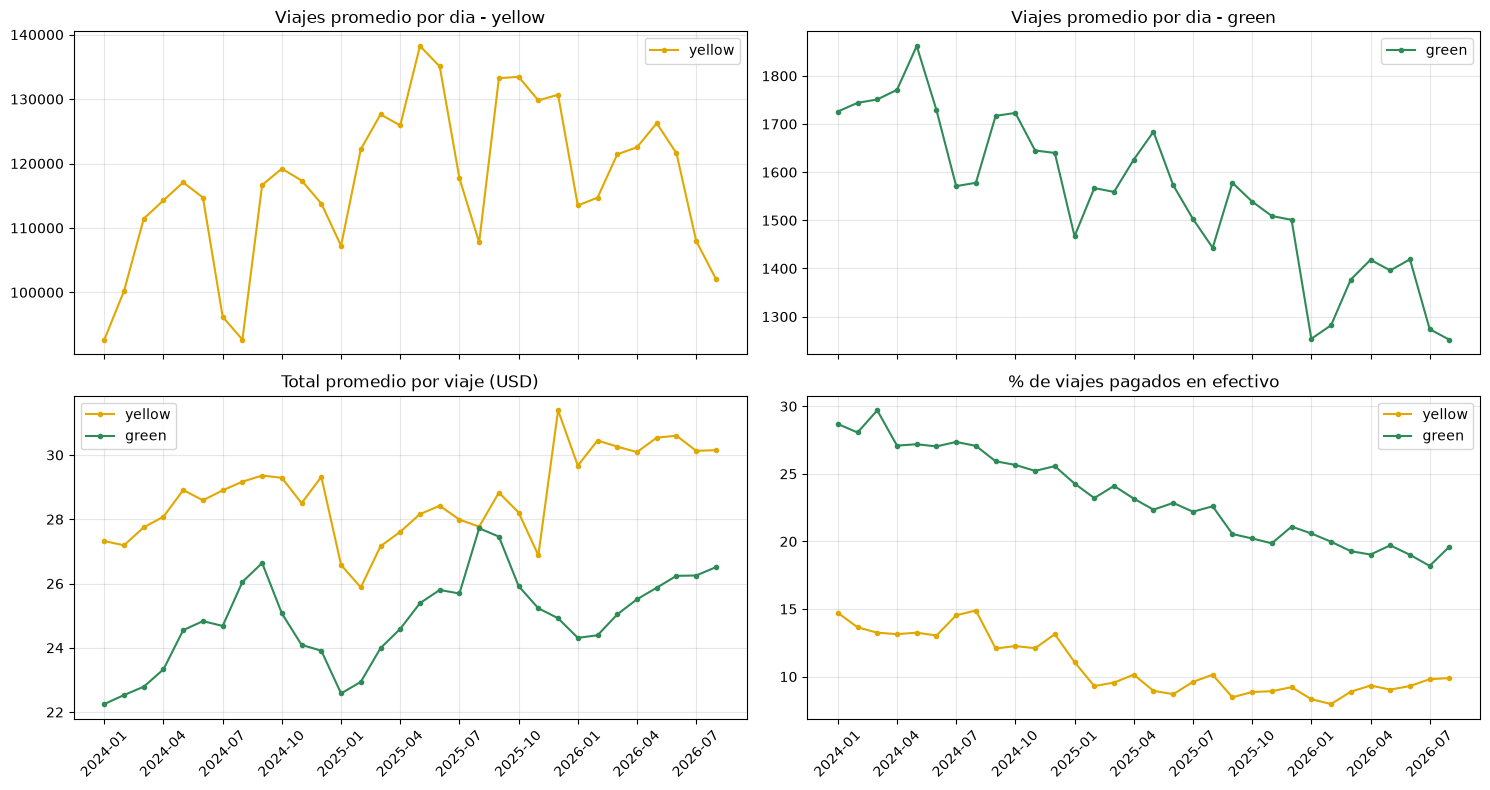

In [12]:
mensual = consulta("sql/08_analisis/02_evolucion_mensual.sql", tablero)

fig, ejes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
paneles = [
    ("viajes_por_dia", "Viajes promedio por dia", "yellow"),
    ("viajes_por_dia", "Viajes promedio por dia", "green"),
    ("total_promedio", "Total promedio por viaje (USD)", None),
    ("pct_efectivo", "% de viajes pagados en efectivo", None),
]
for eje, (columna, titulo, solo_tipo) in zip(ejes.flat, paneles):
    for tipo in ([solo_tipo] if solo_tipo else ["yellow", "green"]):
        datos = mensual[mensual["tipo"] == tipo]
        eje.plot(datos["periodo"], datos[columna], marker="o", markersize=3, color=COLORES[tipo], label=tipo)
    eje.set_title(titulo + (f" - {solo_tipo}" if solo_tipo else ""))
    eje.legend()
    eje.grid(alpha=0.3)
for eje in ejes[1]:
    etiquetas = sorted(mensual["periodo"].unique())
    eje.set_xticks(range(0, len(etiquetas), 3), etiquetas[::3], rotation=45)
plt.tight_layout()
plt.show()

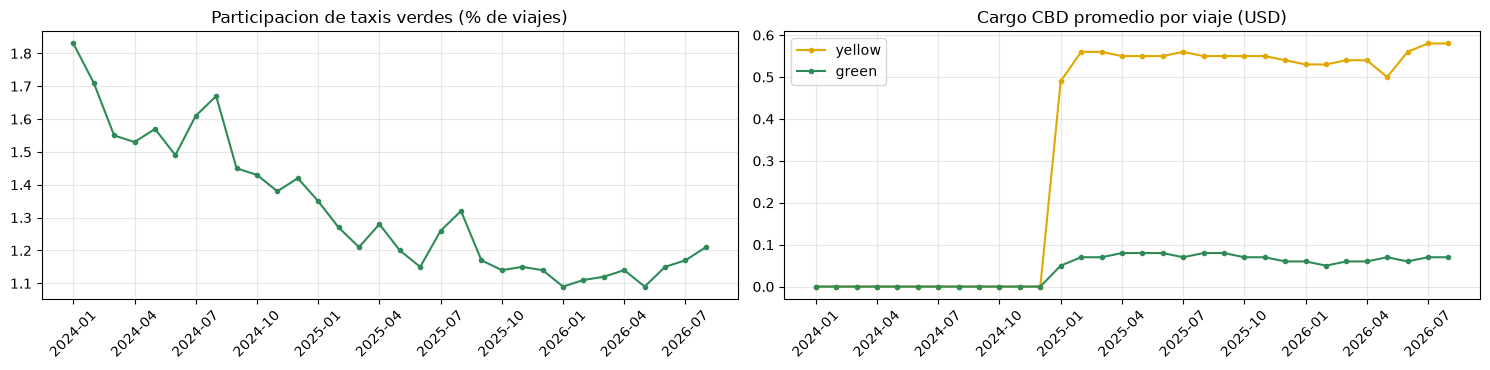

In [13]:
participacion = mensual[mensual["tipo"] == "green"][["periodo", "pct_green", "cbd_promedio"]]
fig, ejes = plt.subplots(1, 2, figsize=(15, 3.8))
ejes[0].plot(participacion["periodo"], participacion["pct_green"], marker="o", markersize=3, color=COLORES["green"])
ejes[0].set_title("Participacion de taxis verdes (% de viajes)")
for tipo in ["yellow", "green"]:
    datos = mensual[mensual["tipo"] == tipo]
    ejes[1].plot(datos["periodo"], datos["cbd_promedio"], marker="o", markersize=3, color=COLORES[tipo], label=tipo)
ejes[1].set_title("Cargo CBD promedio por viaje (USD)")
ejes[1].legend()
for eje in ejes:
    etiquetas = sorted(mensual["periodo"].unique())
    eje.set_xticks(range(0, len(etiquetas), 3), etiquetas[::3], rotation=45)
    eje.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Resultado:**

- **Viajes por día (amarillos):** se repite el mismo patrón estacional cada año, con caídas en enero y en julio–agosto, pero el nivel es mayor en 2025 (máximo de ~138 mil por día en mayo de 2025).
- **Viajes por día (verdes):** tendencia descendente continua, de ~1,860 por día (mayo de 2024) a ~1,250 (agosto de 2026).
- **Participación de verdes:** baja de 1.83% (enero de 2024) a ~1.1–1.2% en 2026.
- **Efectivo:** cae de forma sostenida en verdes (de ~29% a ~19%). En amarillos baja en escalón al inicio de 2025 (de ~13% a ~9–10%) y luego se estabiliza.
- **Cargo CBD:** aparece en **enero de 2025**. Desde entonces aporta ~0.55 USD por viaje amarillo y ~0.07 USD por viaje verde, lo que confirma que los amarillos operan mucho más en el centro de Manhattan.

### Distribución horaria y velocidad por año

Consultas: `sql/08_analisis/03_viajes_por_hora_anio.sql` y `sql/08_analisis/04_velocidad_anio.sql`. La velocidad de la tarde corresponde a los viajes iniciados entre las 14:00 y las 18:59.

-- Ejercicio 8 - Porcentaje de viajes por hora de inicio, por anio y tipo de taxi.
-- Fuente: data/processed/tablero.duckdb (tabla ind_03_viajes_por_hora).
SELECT anio, tipo, hora, pct_viajes
FROM ind_03_viajes_por_hora
ORDER BY tipo, anio, hora;

-- Ejercicio 8 - Velocidad promedio (mph) por anio y tipo de taxi: total del dia y franja 14:00-18:59.
-- Fuente: data/processed/tablero.duckdb (tabla ind_08_velocidad_por_hora).
SELECT
    anio,
    tipo,
    round(sum(distancia_total_mi) / sum(horas_total), 2)                              AS velocidad_dia_mph,
    round(sum(distancia_total_mi) FILTER (WHERE hora BETWEEN 14 AND 18)
          / sum(horas_total) FILTER (WHERE hora BETWEEN 14 AND 18), 2)                AS velocidad_tarde_mph
FROM ind_08_velocidad_por_hora
GROUP BY anio, tipo
ORDER BY tipo, anio;



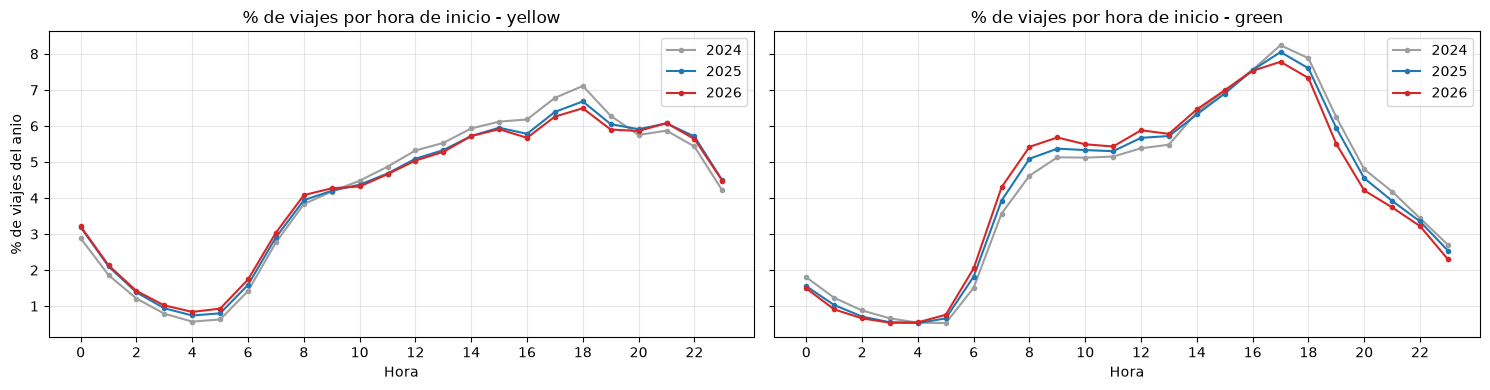

,anio,tipo,velocidad_dia_mph,velocidad_tarde_mph
0,2024,green,8.91,8.27
1,2025,green,8.95,8.63
2,2026,green,9.50,8.76
3,2024,yellow,11.66,10.23
4,2025,yellow,11.91,10.25
5,2026,yellow,11.76,10.16


In [14]:
horas = consulta("sql/08_analisis/03_viajes_por_hora_anio.sql", tablero)
velocidad = consulta("sql/08_analisis/04_velocidad_anio.sql", tablero)

fig, ejes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
for eje, tipo in zip(ejes, ["yellow", "green"]):
    for anio, datos in horas[horas["tipo"] == tipo].groupby("anio"):
        eje.plot(datos["hora"], datos["pct_viajes"], marker="o", markersize=3, color=COLORES_ANIO[anio], label=str(anio))
    eje.set_title(f"% de viajes por hora de inicio - {tipo}")
    eje.set_xlabel("Hora")
    eje.set_xticks(range(0, 24, 2))
    eje.legend()
    eje.grid(alpha=0.3)
ejes[0].set_ylabel("% de viajes del anio")
plt.tight_layout()
plt.show()
velocidad

**Resultado:**

- **Amarillos:** el pico de las 17:00–18:00 se reduce (18:00: de 7.1% en 2024 a ~6.5% en 2026) y aumenta la proporción de viajes de madrugada (0:00–5:00). La demanda se reparte un poco más a lo largo del día.
- **Verdes:** aumenta la proporción de viajes por la mañana (7:00–13:00) y disminuye la de la noche (19:00–23:00).
- **Velocidad:** prácticamente estable en los amarillos (~11.7–11.9 mph en el día y ~10.2 mph en la tarde). En los verdes aumenta levemente (de 8.91 a 9.50 mph en el día).

## 8.6 Cambios y patrones al considerar 2024, 2025 y 2026

1. **Los dos servicios evolucionan en sentidos opuestos.** Los taxis amarillos aumentan su demanda en 2025 (+17% de viajes por día en enero–agosto) y en 2026 siguen por encima de 2024. Los verdes pierden viajes todos los años (−22% entre 2024 y 2026) y su participación cae de ~1.8% a ~1.1%. Con un solo año, esta tendencia no se habría podido distinguir de la estacionalidad.
2. **El efectivo desaparece gradualmente.** El pago en efectivo baja cada año en ambos tipos: en verdes de 27.8% a 19.4% y en amarillos de 13.8% a 9.1%.
3. **La política de precios por congestión se observa en los datos.** El cargo CBD aparece en enero de 2025 como un escalón (~0.55 USD por viaje amarillo) y eleva el peso de los recargos en los amarillos de 7.4% a 8.5% del total en 2025.
4. **La calidad de los datos empeora con el tiempo.** Los viajes *Flex Fare / sin dato*, que no registran pasajeros, tipo de tarifa ni recargo de congestión, pasan de 9% a 25% en amarillos y de 4% a 15% en verdes. Por ejemplo, en 2026 el peso de los recargos vuelve a 7.4% aunque el cargo CBD sigue vigente, porque esos viajes cuentan como 0. Los indicadores que usan estas columnas deben interpretarse con cuidado al comparar años.
5. **El patrón estacional se repite cada año.** Los amarillos caen en enero y en julio–agosto en los tres años. La comparación entre años debe hacerse con los mismos meses, como en el resumen de enero–agosto.

## 8.7 Consultas utilizadas

| Consulta | Uso |
|----------|-----|
| `sql/05_incorporacion/01_*` a `06_*` | Verificación de archivos, registros, esquema y consulta conjunta por año. |
| `sql/03_exploracion/*`, `sql/04_eda/*` | Consultas anteriores ejecutadas sin cambios (8.3). |
| `sql/07_indicadores/*.sql` | Tablas de indicadores reconstruidas con los tres años. |
| `sql/07_indicadores/tablero/03_*`, `04_*`, `08_*` | Visualizaciones del tablero actualizadas para comparar años. |
| `sql/08_analisis/01_resumen_anual.sql` | Resumen anual comparable (enero–agosto). |
| `sql/08_analisis/02_evolucion_mensual.sql` | Evolución mensual de los indicadores principales. |
| `sql/08_analisis/03_viajes_por_hora_anio.sql` | Distribución horaria por año. |
| `sql/08_analisis/04_velocidad_anio.sql` | Velocidad promedio por año. |